<a href="https://colab.research.google.com/github/mennasherif14/multimodal-meme-analyzer/blob/main/deept111.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
{"username":"mostafawahid","key":"6c808c9cf45d41d268704c1534de987b"}

{'username': 'mostafawahid', 'key': '6c808c9cf45d41d268704c1534de987b'}

In [2]:
# ── 1. Install & Setup Kaggle ────────────────────────────────────────────────
!pip install kaggle -q

from google.colab import files

# Upload kaggle.json
files.upload()

# Create kaggle folder and move file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [3]:
# ── 2. Download Facebook Images (Kaggle) ────────────────────────────────────
!kaggle datasets download -d parthplc/facebook-hateful-meme-dataset -q

# Extract dataset
!unzip -q facebook-hateful-meme-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/parthplc/facebook-hateful-meme-dataset
License(s): unknown
User cancelled operation
[facebook-hateful-meme-dataset.zip]
  End-of-central-directory signature not found.  Either this file is not
  a zipfile, or it constitutes one disk of a multi-part archive.  In the
  latter case the central directory and zipfile comment will be found on
  the last disk(s) of this archive.
unzip:  cannot find zipfile directory in one of facebook-hateful-meme-dataset.zip or
        facebook-hateful-meme-dataset.zip.zip, and cannot find facebook-hateful-meme-dataset.zip.ZIP, period.


In [4]:
# ── 3. Download 9gag Images (GitHub) ────────────────────────────────────────
!git clone https://github.com/mennasherif14/multimodal-meme-analyzer.git

Cloning into 'multimodal-meme-analyzer'...
remote: Enumerating objects: 1017, done.
remote: Counting objects: 100% (1017/1017), done.
remote: Compressing objects: 100% (1016/1016), done.
remote: Total 1017 (delta 4), reused 1008 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (1017/1017), 44.78 MiB | 17.86 MiB/s, done.
Resolving deltas: 100% (4/4), done.


In [5]:
# ── 4. Import Libraries ─────────────────────────────────────────────────────
import pandas as pd
import os
from google.colab import files

In [6]:
# ── 5. Upload merged_dataset.csv ────────────────────────────────────────────
files.upload()

Saving merged_dataset.csv to merged_dataset.csv


{'merged_dataset.csv': b'id,img,label,text,weight\n0,/content/data/img/27613.png,0,april 15th is coming... bitches better have my money... memegenerator.ne bitches better have my money.,1.0\n1,/content/data/img/10932.png,0,you come home and found this.. what do you do ???,1.0\n2,/content/data/img/73980.png,0,i caught my goat cheating on me,1.0\n3,/content/data/img/06823.png,1,removes polish with chemicals nobody bats an eye removes polish with chemicals everybody loses his shit,1.0\n4,/content/data/img/91385.png,0,you can tell the gender of an ant by throwing it in water if it sinks= girl ant...if it floats= buoyant,1.0\n5,/content/data/img/28613.png,1,if slavery had cellphones on the plantation like fuck massah,1.0\n6,/content/data/img/81956.png,0,sharks don\'t attack him why? they think it\'s whale shit,1.0\n7,/content/data/img/86329.png,1,muslim 49 people were killed at christchurch mosques muslim 49 people were killed at christchurch,1.0\n8,/content/data/img/03429.png,0,throwback t

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [7]:
# ── 6. Load CSV File ────────────────────────────────────────────────────────
merged = pd.read_csv("merged_dataset.csv")

# Preview
merged.head()

,id,img,label,text,weight
0,0,/content/data/img/27613.png,0,april 15th is coming... bitches better have my...,1.0
1,1,/content/data/img/10932.png,0,you come home and found this.. what do you do ???,1.0
2,2,/content/data/img/73980.png,0,i caught my goat cheating on me,1.0
3,3,/content/data/img/06823.png,1,removes polish with chemicals nobody bats an e...,1.0
4,4,/content/data/img/91385.png,0,you can tell the gender of an ant by throwing ...,1.0


In [8]:
 # ── 7. Fix Image Paths ──────────────────────────────────────────────────────
def fix_path(p):
    filename = os.path.basename(p)

    # 9gag images
    if "9gag" in p or "multimodal" in p:
        return f"/content/multimodal-meme-analyzer/9gag_memes/{filename}"

    # Facebook dataset images
    else:
        return f"/content/data/img/{filename}"

# Apply function
merged["img"] = merged["img"].apply(fix_path)

In [9]:
# ── 8. Verify Images Exist ──────────────────────────────────────────────────
missing = merged["img"].apply(lambda p: not os.path.exists(p)).sum()

print(f"✅ Missing images: {missing}")
print("\nDataset Shape:")
print(merged.shape)

print("\nLabel Distribution:")
print(merged["label"].value_counts())

✅ Missing images: 8500

Dataset Shape:
(9487, 5)

Label Distribution:
label
0    6330
1    3157
Name: count, dtype: int64


In [10]:
# ── 9. Split Dataset ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    merged,
    test_size=0.2,
    random_state=42,
    stratify=merged["label"]
)

# Reset index
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

In [11]:
# ── 10. Check Final Split ───────────────────────────────────────────────────
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")

print("\nTrain Labels Distribution:")
print(train_df["label"].value_counts())

Train: 7589
Validation: 1898

Train Labels Distribution:
label
0    5064
1    2525
Name: count, dtype: int64


In [12]:
# ── 10. Check Final Split ───────────────────────────────────────────────────
print(f"Train: {len(train_df)}")
print(f"Validation: {len(val_df)}")

print("\nTrain Labels Distribution:")
print(train_df["label"].value_counts())

Train: 7589
Validation: 1898

Train Labels Distribution:
label
0    5064
1    2525
Name: count, dtype: int64


In [13]:
# ── 11. Install Required Libraries ──────────────────────────────────────────
!pip install transformers torch torchvision Pillow scikit-learn -q
!pip install accelerate -q

print('✅ Libraries installed!')

✅ Libraries installed!


In [14]:
# ── 12. Import Libraries ─────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

from transformers import CLIPProcessor, CLIPModel

from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    classification_report, confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Device ───────────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'✅ Using device: {DEVICE}')

✅ Using device: cuda


In [15]:
# ── 13. Config ───────────────────────────────────────────────────────────────
class CFG:
    MODEL_NAME    = 'openai/clip-vit-base-patch32'
    MAX_LEN       = 77
    IMAGE_SIZE    = 224
    BATCH_SIZE    = 32
    EPOCHS        = 10
    LR            = 5e-6        # ✅ وسط بين 1e-5 و 1e-6
    WEIGHT_DECAY  = 5e-2        # ✅ وسط
    DROPOUT       = 0.4         # ✅ وسط
    SEED          = 42
    UNFREEZE_LAST = 2           # ✅ رجّع 2

torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)
print('✅ Config loaded!')

✅ Config loaded!


In [16]:
# ── 14. Dataset Class ────────────────────────────────────────────────────────
class MemeDataset(Dataset):
    def __init__(self, df, processor, is_train=True):
        self.df        = df.reset_index(drop=True)
        self.processor = processor
        self.is_train  = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            image = Image.open(row['img']).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))

        text = str(row['text']) if pd.notna(row['text']) else ''

        inputs = self.processor(
            text            = text,
            images          = image,
            return_tensors  = 'pt',
            padding         = 'max_length',
            truncation      = True,
            max_length      = CFG.MAX_LEN,
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}
        item['labels'] = torch.tensor(int(row['label']), dtype=torch.long)

        if 'weight' in row:
            item['weight'] = torch.tensor(float(row['weight']), dtype=torch.float)

        return item

print('✅ MemeDataset class defined!')


✅ MemeDataset class defined!


In [17]:
import torch.nn.functional as F

class CLIPHatefulMemeClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.clip = CLIPModel.from_pretrained(model_name)

        for param in self.clip.parameters():
            param.requires_grad = False

        for layer in list(self.clip.vision_model.encoder.layers)[-CFG.UNFREEZE_LAST:]:
            for param in layer.parameters():
                param.requires_grad = True

        for layer in list(self.clip.text_model.encoder.layers)[-CFG.UNFREEZE_LAST:]:
            for param in layer.parameters():
                param.requires_grad = True

        embed_dim = self.clip.config.projection_dim

        self.classifier = nn.Sequential(
            nn.Linear(embed_dim * 2, 512),
            nn.LayerNorm(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2),
        )

    def forward(self, input_ids, attention_mask, pixel_values):
        # ✅ استخدم outputs كاملة وبعدين اسحب الـ tensor
        outputs = self.clip(
            input_ids=input_ids,
            attention_mask=attention_mask,
            pixel_values=pixel_values,
        )
        image_embeds = F.normalize(outputs.image_embeds, dim=-1)
        text_embeds  = F.normalize(outputs.text_embeds,  dim=-1)

        fused  = torch.cat([image_embeds, text_embeds], dim=-1)
        logits = self.classifier(fused)
        return logits

print('✅ CLIPHatefulMemeClassifier FINAL defined!')

✅ CLIPHatefulMemeClassifier FINAL defined!


In [18]:
# ── 16. Load CLIP Processor & Model ─────────────────────────────────────────
print('⏳ Loading CLIP processor and model...')

processor = CLIPProcessor.from_pretrained(CFG.MODEL_NAME)
model     = CLIPHatefulMemeClassifier(CFG.MODEL_NAME, dropout=CFG.DROPOUT)
model     = model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'✅ Model loaded!')
print(f'   Total params:     {total_params:,}')
print(f'   Trainable params: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)')

⏳ Loading CLIP processor and model...


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Model loaded!
   Total params:     151,935,491
   Trainable params: 21,138,690 (13.9%)


In [19]:
# ── 17. Create DataLoaders ───────────────────────────────────────────────────
train_dataset = MemeDataset(train_df, processor, is_train=True)
val_dataset   = MemeDataset(val_df,   processor, is_train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True if DEVICE == 'cuda' else False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True if DEVICE == 'cuda' else False,
)

print(f'✅ DataLoaders ready!')
print(f'   Train batches: {len(train_loader)}')
print(f'   Val batches:   {len(val_loader)}')

✅ DataLoaders ready!
   Train batches: 238
   Val batches:   60


In [20]:
# ── 18. Loss Function ────────────────────────────────────────────────────────
num_neg    = (train_df['label'] == 0).sum()
num_pos    = (train_df['label'] == 1).sum()
pos_weight = num_neg / num_pos

class_weights = torch.tensor([1.0, pos_weight], dtype=torch.float).to(DEVICE)
criterion     = nn.CrossEntropyLoss(weight=class_weights)

print(f'✅ Loss: CrossEntropyLoss')
print(f'   Class weights → Not Hateful: 1.0 | Hateful: {pos_weight:.2f}')

✅ Loss: CrossEntropyLoss
   Class weights → Not Hateful: 1.0 | Hateful: 2.01


In [21]:
# ── 19. Optimizer & Scheduler ────────────────────────────────────────────────
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = CFG.LR,
    weight_decay = CFG.WEIGHT_DECAY,
)

scheduler = CosineAnnealingLR(
    optimizer,
    T_max   = CFG.EPOCHS,
    eta_min = 1e-7,
)

print('✅ Optimizer: AdamW')
print('✅ Scheduler: CosineAnnealingLR')

✅ Optimizer: AdamW
✅ Scheduler: CosineAnnealingLR


In [22]:
# ── 20. Training & Validation Functions ──────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for batch in loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        pixel_values   = batch['pixel_values'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        logits = model(input_ids, attention_mask, pixel_values)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


def validate(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            pixel_values   = batch['pixel_values'].to(device)
            labels         = batch['labels'].to(device)

            logits = model(input_ids, attention_mask, pixel_values)
            loss   = criterion(logits, labels)

            total_loss += loss.item()
            probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            preds  = logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs)

    acc = accuracy_score(all_labels, all_preds)
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / len(loader), acc, auc, all_preds, all_labels

print('✅ Training functions ready!')

✅ Training functions ready!


In [23]:
# ── 20.5 Improvements ────────────────────────────────────────────────────────
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torchvision.transforms as T

# ── 1. Data Augmentation للـ Training ────────────────────────────────────────
augment = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomGrayscale(p=0.1),
])

class MemeDatasetAug(Dataset):
    """نفس الـ MemeDataset بس بيعمل Augmentation على الـ training data"""
    def __init__(self, df, processor, is_train=True):
        self.df        = df.reset_index(drop=True)
        self.processor = processor
        self.is_train  = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        try:
            image = Image.open(row['img']).convert('RGB')
        except Exception:
            image = Image.new('RGB', (224, 224), color=(255, 255, 255))

        # Augment فقط على الـ training
        if self.is_train:
            image = augment(image)

        text = str(row['text']) if pd.notna(row['text']) else ''

        inputs = self.processor(
            text           = text,
            images         = image,
            return_tensors = 'pt',
            padding        = 'max_length',
            truncation     = True,
            max_length     = CFG.MAX_LEN,
        )

        item = {k: v.squeeze(0) for k, v in inputs.items()}
        item['labels'] = torch.tensor(int(row['label']), dtype=torch.long)
        return item


# ── 2. Early Stopping ─────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, val_auc):
        if self.best_score is None:
            self.best_score = val_auc
        elif val_auc < self.best_score + self.min_delta:
            self.counter += 1
            print(f'   ⚠️ EarlyStopping counter: {self.counter}/{self.patience}')
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = val_auc
            self.counter    = 0


# ── 3. أعد بناء الـ DataLoaders بالـ Augmentation ────────────────────────────
train_dataset = MemeDatasetAug(train_df, processor, is_train=True)
val_dataset   = MemeDatasetAug(val_df,   processor, is_train=False)

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = True,
    num_workers = 2,
    pin_memory  = True if DEVICE == 'cuda' else False,
)

val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = False,
    num_workers = 2,
    pin_memory  = True if DEVICE == 'cuda' else False,
)

# ── 4. Scheduler أحسن (ReduceLROnPlateau) ────────────────────────────────────
sscheduler = ReduceLROnPlateau(
    optimizer,
    mode     = 'max',
    factor   = 0.5,
    patience = 2,
    # verbose  = True,  ← اشيل السطر ده
)
# ── 5. Early Stopping instance ────────────────────────────────────────────────
early_stopping = EarlyStopping(patience=3, min_delta=0.001)

print('✅ Augmentation ready!')
print('✅ Early Stopping ready!')
print('✅ ReduceLROnPlateau ready!')
print('✅ DataLoaders rebuilt with Augmentation!')

✅ Augmentation ready!
✅ Early Stopping ready!
✅ ReduceLROnPlateau ready!
✅ DataLoaders rebuilt with Augmentation!


In [24]:
# ── 21. Training Loop ────────────────────────────────────────────────────────
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [], 'val_auc': []
}

best_auc        = 0.0
best_model_path = '/content/best_clip_meme_model.pt'

print('🚀 Starting Training...')
print('=' * 60)

for epoch in range(1, CFG.EPOCHS + 1):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE
    )
    val_loss, val_acc, val_auc, _, _ = validate(
        model, val_loader, criterion, DEVICE
    )
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_auc'].append(val_auc)

    if val_auc > best_auc:
        best_auc = val_auc
        torch.save(model.state_dict(), best_model_path)
        saved_flag = '  ✅ Saved!'
    else:
        saved_flag = ''

    print(
        f'Epoch [{epoch:02d}/{CFG.EPOCHS}] '
        f'| Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} '
        f'| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} '
        f'| Val AUC: {val_auc:.4f}'
        f'{saved_flag}'
    )

print('=' * 60)
print(f'🏆 Best Val AUC: {best_auc:.4f}')

🚀 Starting Training...
Epoch [01/10] | Train Loss: 0.6873 | Train Acc: 0.5658 | Val Loss: 0.6169 | Val Acc: 0.6928 | Val AUC: 0.7309  ✅ Saved!
Epoch [02/10] | Train Loss: 0.6378 | Train Acc: 0.6419 | Val Loss: 0.5947 | Val Acc: 0.7413 | Val AUC: 0.7539  ✅ Saved!
Epoch [03/10] | Train Loss: 0.6015 | Train Acc: 0.6838 | Val Loss: 0.5719 | Val Acc: 0.7234 | Val AUC: 0.7686  ✅ Saved!
Epoch [04/10] | Train Loss: 0.5760 | Train Acc: 0.7108 | Val Loss: 0.5796 | Val Acc: 0.6723 | Val AUC: 0.7754  ✅ Saved!
Epoch [05/10] | Train Loss: 0.5569 | Train Acc: 0.7234 | Val Loss: 0.5767 | Val Acc: 0.6981 | Val AUC: 0.7787  ✅ Saved!
Epoch [06/10] | Train Loss: 0.5454 | Train Acc: 0.7345 | Val Loss: 0.5749 | Val Acc: 0.7086 | Val AUC: 0.7797  ✅ Saved!
Epoch [07/10] | Train Loss: 0.5380 | Train Acc: 0.7429 | Val Loss: 0.5759 | Val Acc: 0.7176 | Val AUC: 0.7805  ✅ Saved!
Epoch [08/10] | Train Loss: 0.5297 | Train Acc: 0.7512 | Val Loss: 0.5777 | Val Acc: 0.7055 | Val AUC: 0.7812  ✅ Saved!
Epoch [09/10] | T

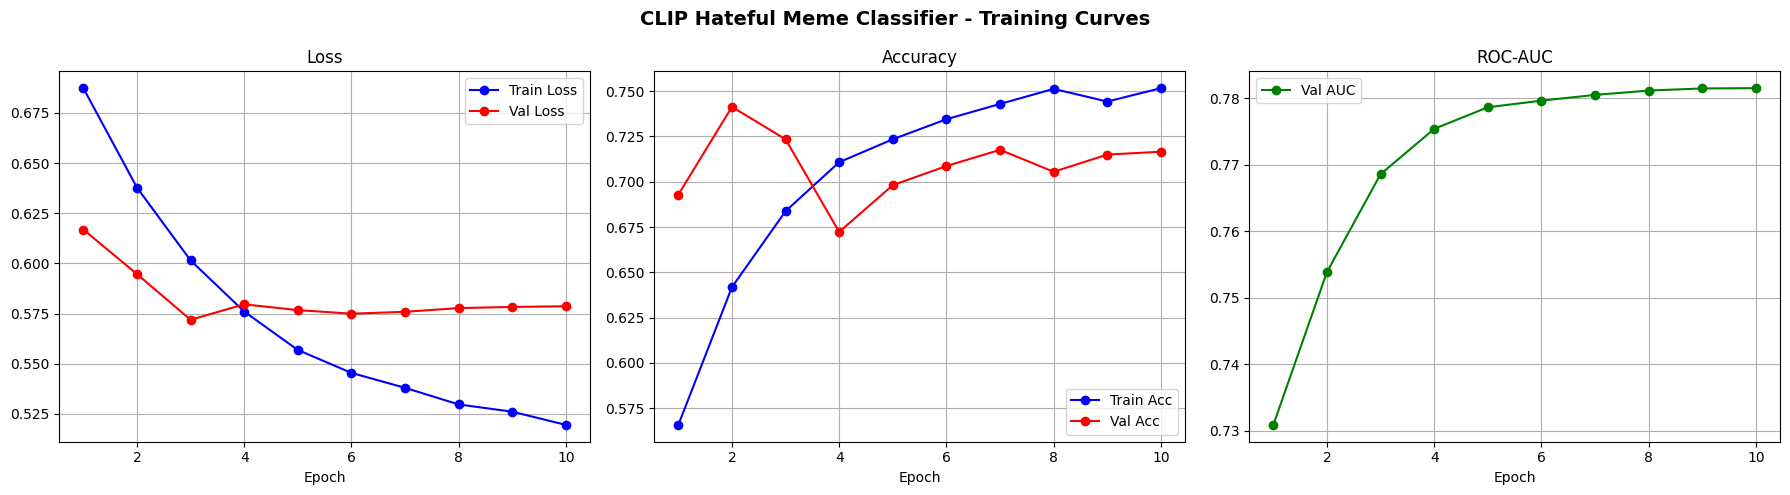

In [25]:
epochs_range = range(1, CFG.EPOCHS + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CLIP Hateful Meme Classifier - Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, history['train_loss'], 'b-o', label='Train Loss')
axes[0].plot(epochs_range, history['val_loss'],   'r-o', label='Val Loss')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_range, history['train_acc'], 'b-o', label='Train Acc')
axes[1].plot(epochs_range, history['val_acc'],   'r-o', label='Val Acc')
axes[1].set_title('Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_range, history['val_auc'], 'g-o', label='Val AUC')
axes[2].set_title('ROC-AUC'); axes[2].set_xlabel('Epoch')
axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()

In [26]:
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

_, val_acc, val_auc, all_preds, all_labels = validate(
    model, val_loader, criterion, DEVICE
)

print('📊 Final Evaluation on Validation Set')
print('=' * 50)
print(f'   Accuracy : {val_acc:.4f}')
print(f'   ROC-AUC  : {val_auc:.4f}')
print()
print(classification_report(
    all_labels, all_preds,
    target_names=['Not Hateful', 'Hateful']
))

📊 Final Evaluation on Validation Set
   Accuracy : 0.7165
   ROC-AUC  : 0.7815

              precision    recall  f1-score   support

 Not Hateful       0.82      0.74      0.78      1266
     Hateful       0.56      0.67      0.61       632

    accuracy                           0.72      1898
   macro avg       0.69      0.71      0.69      1898
weighted avg       0.73      0.72      0.72      1898



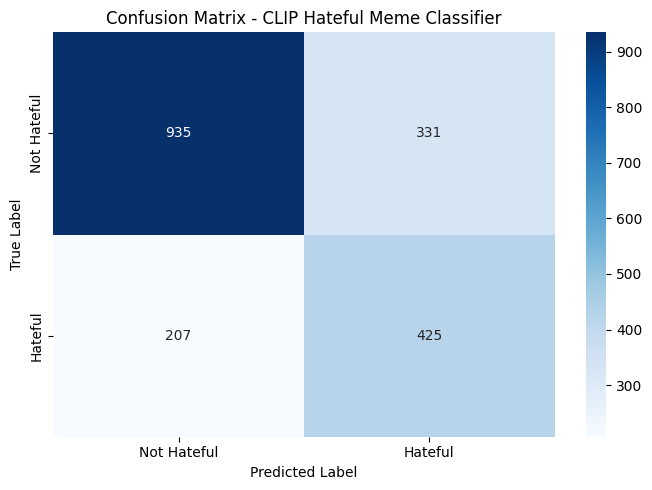

In [27]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Not Hateful', 'Hateful'],
    yticklabels=['Not Hateful', 'Hateful']
)
plt.title('Confusion Matrix - CLIP Hateful Meme Classifier')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

✅ صور موجودة: 200 من 1898
--------------------------------------------------


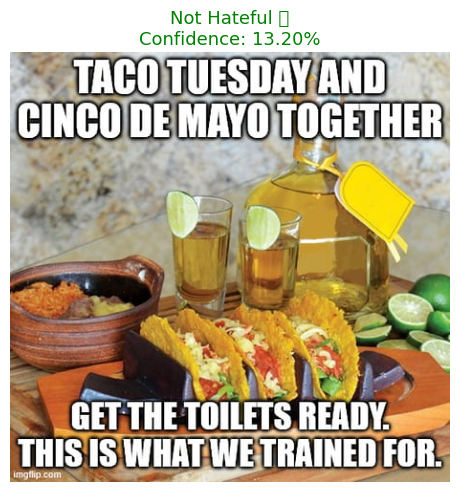

📝 Text   : ataco tuesday and code mavo together reer se myn ms ne a i a ey ore et a s get the toilets ready this 1s what wet rained for
🔮 Result : Not Hateful ✅
📊 Hateful probability: 13.20%
✅ True Label: Not Hateful
--------------------------------------------------


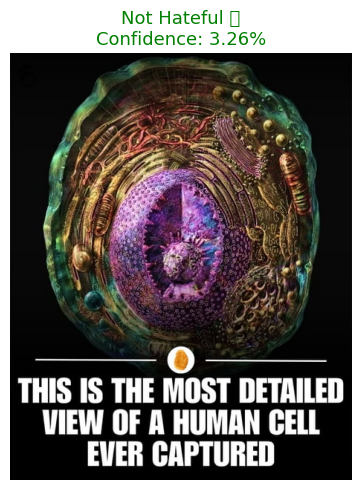

📝 Text   : a oe se a yo wv
🔮 Result : Not Hateful ✅
📊 Hateful probability: 3.26%
✅ True Label: Not Hateful
--------------------------------------------------


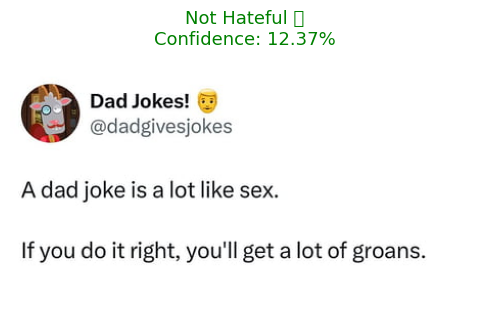

📝 Text   : dad jokes dadgivesjokes a dad joke is a lot like sex if you do it right you ll get a lot of groans
🔮 Result : Not Hateful ✅
📊 Hateful probability: 12.37%
✅ True Label: Not Hateful
--------------------------------------------------


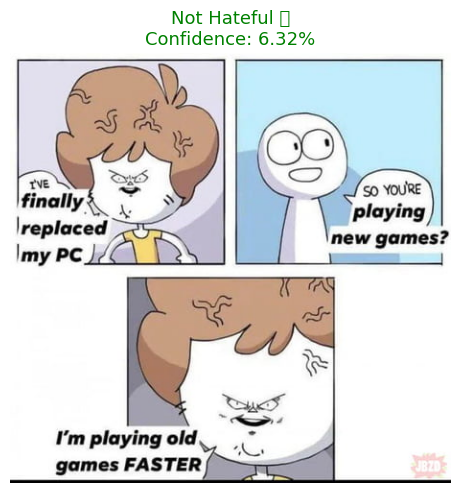

📝 Text   : s so youre yf finally v t playing lreplaced new games imy pc oa an 4 i m playing old c games faster
🔮 Result : Not Hateful ✅
📊 Hateful probability: 6.32%
✅ True Label: Not Hateful
--------------------------------------------------


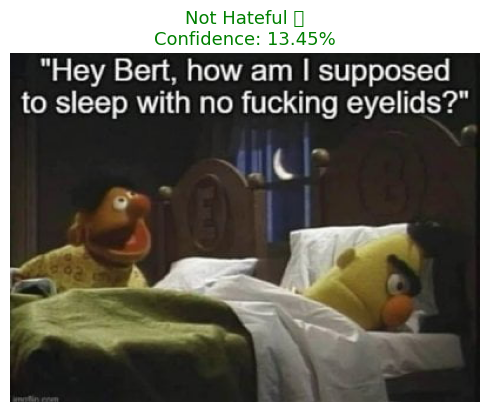

📝 Text   : hey bert how am supposed to sleep with no fucking eyelids o 7 on a
🔮 Result : Not Hateful ✅
📊 Hateful probability: 13.45%
✅ True Label: Not Hateful


In [28]:
# ── 25. Test على صور من الـ val set ──────────────────────────────────────────
def test_meme(image_path, text, model, processor, device, threshold=0.5):
    model.eval()

    # ✅ تحقق إن الصورة موجودة
    if not os.path.exists(image_path):
        print(f'⚠️ صورة مش موجودة: {image_path}')
        return None, None

    image = Image.open(image_path).convert('RGB')

    inputs = processor(
        text           = text,
        images         = image,
        return_tensors = 'pt',
        padding        = 'max_length',
        truncation     = True,
        max_length     = CFG.MAX_LEN,
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs      = model.clip(**inputs)
        image_embeds = torch.nn.functional.normalize(outputs.image_embeds, dim=-1)
        text_embeds  = torch.nn.functional.normalize(outputs.text_embeds,  dim=-1)
        fused        = torch.cat([image_embeds, text_embeds], dim=-1)
        logits       = model.classifier(fused)

    probs      = torch.softmax(logits, dim=-1)[0]
    hateful_p  = probs[1].item()
    prediction = 'Hateful 🚨' if hateful_p >= threshold else 'Not Hateful ✅'

    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis('off')
    plt.title(f'{prediction}\nConfidence: {hateful_p:.2%}', fontsize=13,
              color='red' if hateful_p >= threshold else 'green')
    plt.tight_layout()
    plt.show()

    print(f'📝 Text   : {text}')
    print(f'🔮 Result : {prediction}')
    print(f'📊 Hateful probability: {hateful_p:.2%}')
    return prediction, hateful_p


# ✅ جيب بس الصور الموجودة فعلاً على الـ disk
val_df['img_exists'] = val_df['img'].apply(os.path.exists)
existing_val = val_df[val_df['img_exists'] == True]

print(f'✅ صور موجودة: {len(existing_val)} من {len(val_df)}')

# جرّب على 5 صور موجودة
sample = existing_val.sample(min(5, len(existing_val)), random_state=42)

for _, row in sample.iterrows():
    print('-' * 50)
    test_meme(
        image_path = row['img'],
        text       = row['text'],
        model      = model,
        processor  = processor,
        device     = DEVICE,
    )
    print(f'✅ True Label: {"Hateful" if row["label"] == 1 else "Not Hateful"}')

In [29]:
SAVE_DIR = '/content/clip_meme_classifier'
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save(model.state_dict(), f'{SAVE_DIR}/model_weights.pt')
processor.save_pretrained(f'{SAVE_DIR}/processor')

print(f'✅ Model saved to {SAVE_DIR}/')
print(f'   - model_weights.pt')
print(f'   - processor/')

✅ Model saved to /content/clip_meme_classifier/
   - model_weights.pt
   - processor/


In [32]:
# ── Save Confusion Matrix & Accuracy to Drive ────────────────────────────────
import shutil, os

DRIVE_DIR = '/content/drive/MyDrive/clip_meme_classifier'
os.makedirs(DRIVE_DIR, exist_ok=True)

# حفظ الصور
for fname in ['confusion_matrix.png', 'training_curves.png']:
    src = f'/content/{fname}'
    dst = f'{DRIVE_DIR}/{fname}'
    if os.path.exists(src):
        shutil.copy(src, dst)
        print(f'✅ {fname} saved!')
    else:
        print(f'⚠️  {fname} مش موجود، تأكد إنك رنّت الـ cell بتاعته الأول')

# حفظ الـ accuracy & AUC كـ text file
with open(f'{DRIVE_DIR}/results.txt', 'w') as f:
    f.write(f'Val Accuracy : {val_acc:.4f}\n')
    f.write(f'Val ROC-AUC  : {val_auc:.4f}\n')
    f.write(f'Best AUC     : {best_auc:.4f}\n')

print(f'✅ results.txt saved!')
print(f'\n📁 MyDrive/clip_meme_classifier/')
print(f'   ├── confusion_matrix.png')
print(f'   ├── training_curves.png')
print(f'   └── results.txt')

✅ confusion_matrix.png saved!
✅ training_curves.png saved!
✅ results.txt saved!

📁 MyDrive/clip_meme_classifier/
   ├── confusion_matrix.png
   ├── training_curves.png
   └── results.txt


In [33]:
print('/content/drive/MyDrive/clip_meme_classifier/model_weights.pt')

/content/drive/MyDrive/clip_meme_classifier/model_weights.pt
